# **Modelagem de Imagens Médicas com Grafos de Adjacência de Regiões (RAG)**

### **Configurações**

In [2]:

import matplotlib.pyplot as plt
import networkx as nx
import os
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd

from skimage.segmentation import slic, mark_boundaries
from skimage.measure import regionprops
from skimage.morphology import remove_small_objects, binary_closing, disk


### **Construção do Grafo de Adjacência de Regiões (RAG)**

O grafo é construído a partir dos superpixels, onde cada região representa um nó e as adjacências espaciais definem as arestas.

In [3]:
def construir_rag(segmentos):
    G = nx.Graph()

    labels = np.unique(segmentos)
    for l in labels:
        if l != 0:
            G.add_node(int(l))

    linhas, colunas = segmentos.shape

    vizinhos = [(0,1),(1,0),(1,1),(1,-1)]

    for i in range(linhas):
        for j in range(colunas):

            atual = int(segmentos[i, j])
            if atual == 0:
                continue

            for di, dj in vizinhos:
                ni, nj = i+di, j+dj

                if ni < 0 or ni >= linhas or nj < 0 or nj >= colunas:
                    continue

                vizinho = int(segmentos[ni, nj])

                if vizinho != 0 and atual != vizinho:
                    G.add_edge(atual, vizinho)

    return G

In [4]:
def rotular_superpixels(props, mask_slice, img_norm):

    labels = {}
    pos = {}

    for regiao in props:

        coords = regiao.coords

        tumor_ratio = np.mean(
            mask_slice[coords[:, 0], coords[:, 1]] > 0
        )

        classe = "tumor" if tumor_ratio > 0.5 else "normal"

        labels[regiao.label] = classe

        y, x = regiao.centroid
        pos[regiao.label] = (x, y)

    return labels, pos

In [6]:
def criar_mascara_cerebro(img_norm):
    brain_mask = img_norm > 0.02
    brain_mask = binary_closing(brain_mask, disk(3))
    brain_mask = remove_small_objects(brain_mask, min_size=500)
    return brain_mask


In [9]:
def criar_subgrafos(G, labels):

    tumor = [n for n in G.nodes() if labels[n] == "tumor"]
    normal = [n for n in G.nodes() if labels[n] == "normal"]

    return {
        "tumor": G.subgraph(tumor).copy(),
        "normal": G.subgraph(normal).copy()
    }

In [10]:
def metricas_subgrafo(G):

    graus = [G.degree(n) for n in G.nodes()]

    return {
        "nós": G.number_of_nodes(),
        "arestas": G.number_of_edges(),
        "grau_médio": np.mean(graus) if graus else 0,
        "densidade": nx.density(G),
        "componentes": nx.number_connected_components(G)
    }

### **Carregamento e Pré-processamento da Base BraTS 2020**

In [11]:
raiz = Path(r"DATASET")

pacientes = sorted(raiz.glob("BraTS20_*"))
pasta_paciente = pacientes[0]

flair_path = next(pasta_paciente.glob("*flair*"), None)
mask_path = next(pasta_paciente.glob("*seg*"), None)

if not flair_path or not mask_path:
    raise FileNotFoundError("Arquivos FLAIR ou SEG não foram encontrados na pasta do paciente.")

# PROCESSAMENTO DAS IMAGENS
# Processar imagem FLAIR Fatia 75
img = nib.load(str(flair_path)).get_fdata()
slice_img = np.rot90(img[:, :, 75])

# Normalização Min-Max
img_norm = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min() + 1e-8)

# Processar Mascara
mask = nib.load(str(mask_path)).get_fdata()
mask_slice = np.rot90(mask[:, :, 75])

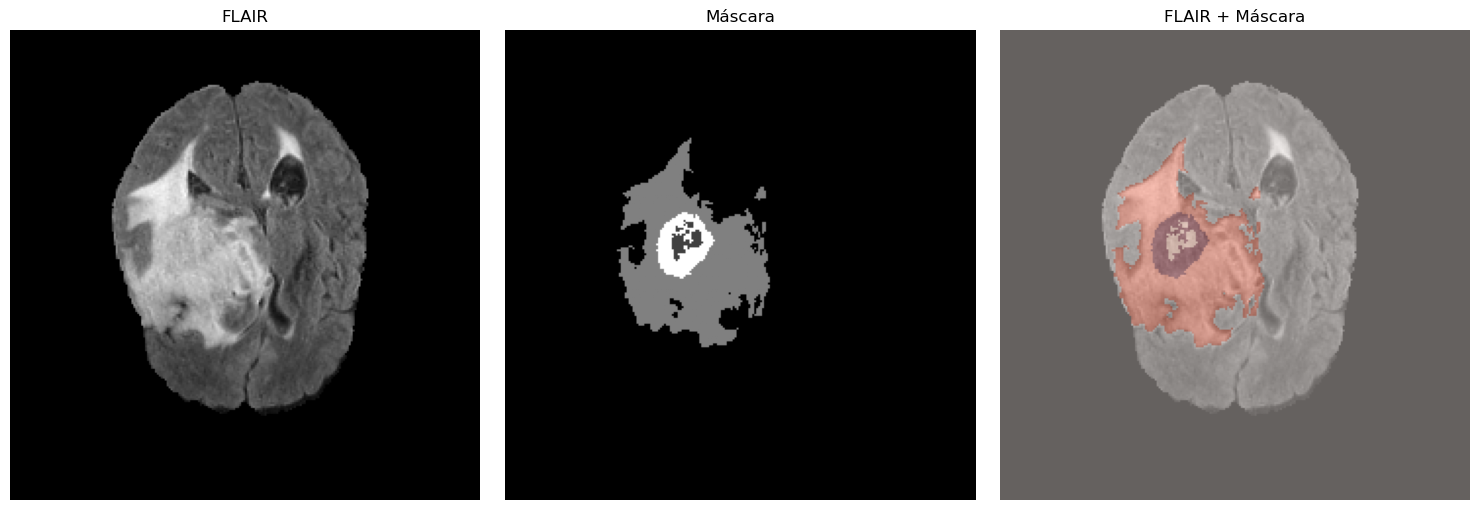

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(slice_img, cmap="gray")
axes[0].set_title("FLAIR")
axes[0].axis("off")

axes[1].imshow(mask_slice, cmap="gray")
axes[1].set_title("Máscara")
axes[1].axis("off")

axes[2].imshow(slice_img, cmap="gray")
axes[2].imshow(mask_slice, cmap="Reds", alpha=0.4)
axes[2].set_title("FLAIR + Máscara")
axes[2].axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

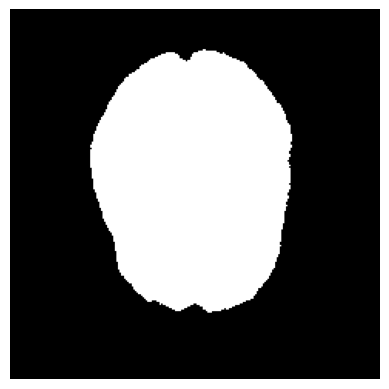

In [13]:
brain_mask = criar_mascara_cerebro(img_norm)

plt.imshow(brain_mask, cmap="gray")
plt.axis("off")

### **Experimento: Variação do número de superpixels**


Executando SLIC com 200 superpixels


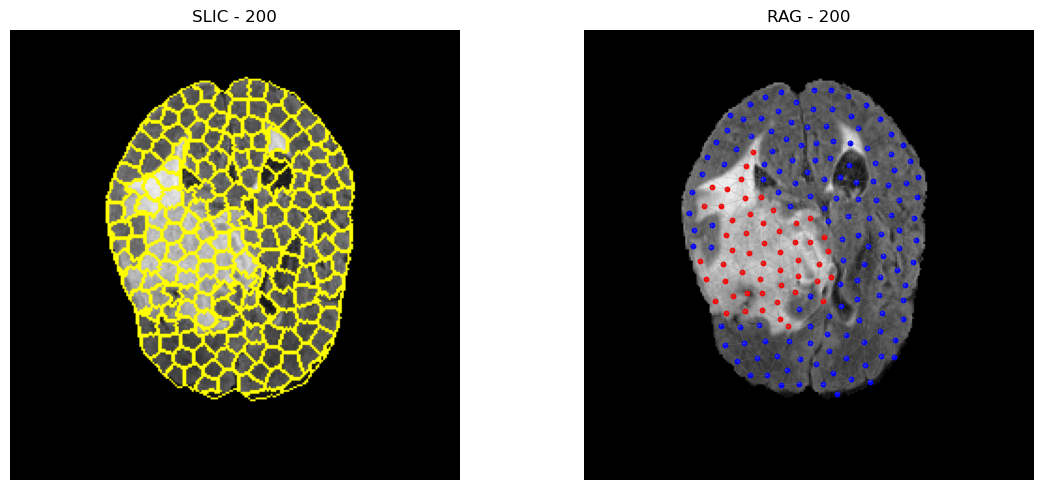


Executando SLIC com 400 superpixels


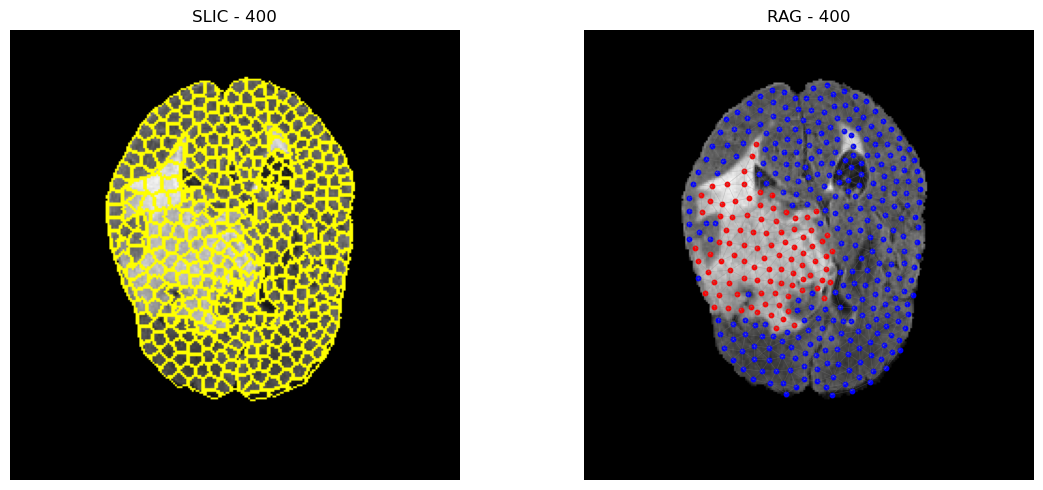


Executando SLIC com 600 superpixels


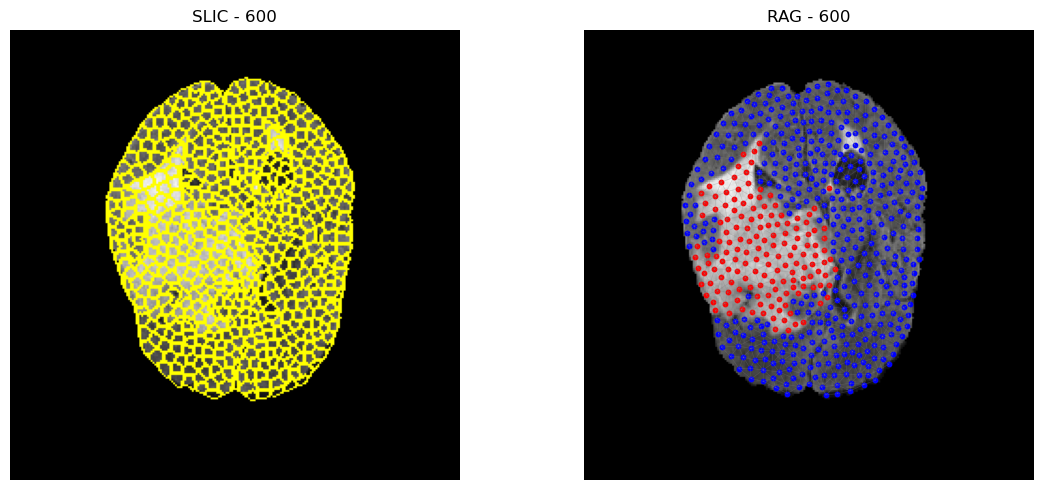


Executando SLIC com 800 superpixels


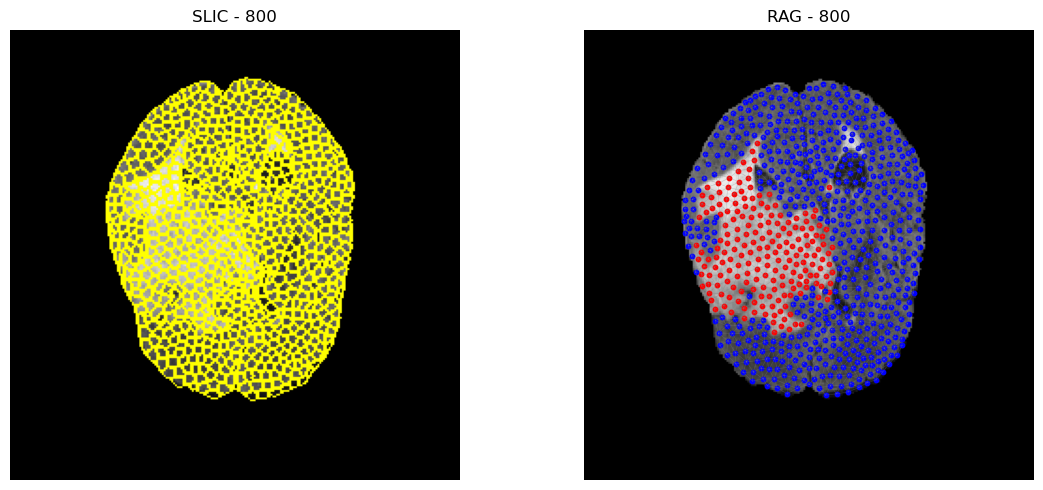

In [14]:
lista_superpixels = [200, 400, 600, 800]

experimentos = {}
resultados = []

for n_seg in lista_superpixels:

    print(f"\nExecutando SLIC com {n_seg} superpixels")

    # SLIC
    segmentos = slic(
        img_norm,
        n_segments=n_seg,
        compactness=0.1,
        start_label=1,
        channel_axis=None,
        mask=brain_mask
    )

    # RAG
    G = construir_rag(segmentos)

    # regiões
    props = regionprops(segmentos)

    # rotulação
    labels, pos = rotular_superpixels(props, mask_slice, img_norm)

    
    # metricas = calcular_metricas(G, labels)

    # resultados.append([
    #     n_seg,
    #     G.number_of_nodes(),
    #     G.number_of_edges(),
    #     metricas["grau_tumor"],
    #     metricas["grau_normal"],
    #     metricas["densidade"],
    #     metricas["componentes"]
    # ])

    experimentos[n_seg] = {
        "segmentos": segmentos,
        "grafo": G,
        "labels": labels,
        "pos": pos
        
    }
    
    # ###########

    exp = experimentos[n_seg]

    segmentos = exp["segmentos"]
    G = exp["grafo"]
    labels = exp["labels"]
    pos = exp["pos"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    
    axes[0].imshow(mark_boundaries(img_norm, segmentos))
    axes[0].set_title(f"SLIC - {n_seg}")
    axes[0].axis("off")

    axes[1].imshow(img_norm, cmap="gray")

    for u, v in G.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        axes[1].plot([x1, x2], [y1, y2], color="gray", alpha=0.3, linewidth=0.5)

    # nós
    tumor_x, tumor_y = [], []
    normal_x, normal_y = [], []

    for node in G.nodes():
        x, y = pos[node]

        if labels[node] == "tumor":
            tumor_x.append(x)
            tumor_y.append(y)
        else:
            normal_x.append(x)
            normal_y.append(y)

    axes[1].scatter(tumor_x, tumor_y, c="red", s=10, label="Tumor")
    axes[1].scatter(normal_x, normal_y, c="blue", s=10, label="Normal")

    axes[1].set_title(f"RAG - {n_seg}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

### **RAG-Subgrafos: tumor vs sem tumor**

In [16]:
resultados_subgrafos = []

for n_seg in lista_superpixels:

    G = experimentos[n_seg]["grafo"]
    labels = experimentos[n_seg]["labels"]

    subgrafos = criar_subgrafos(G, labels)

    G_tumor = subgrafos["tumor"]
    G_normal = subgrafos["normal"]

    mt = metricas_subgrafo(G_tumor)
    mn = metricas_subgrafo(G_normal)

    resultados_subgrafos.append({
        "Superpixels": n_seg,

        # TUMOR
        "Nós Tumor": mt["nós"],
        "Arestas Tumor": mt["arestas"],
        "Grau Médio Tumor": mt["grau_médio"],
        "Densidade Tumor": mt["densidade"],
        "Componentes Tumor": mt["componentes"],

        # NORMAL
        "Nós Normal": mn["nós"],
        "Arestas Normal": mn["arestas"],
        "Grau Médio Normal": mn["grau_médio"],
        "Densidade Normal": mn["densidade"],
        "Componentes Normal": mn["componentes"],
    })



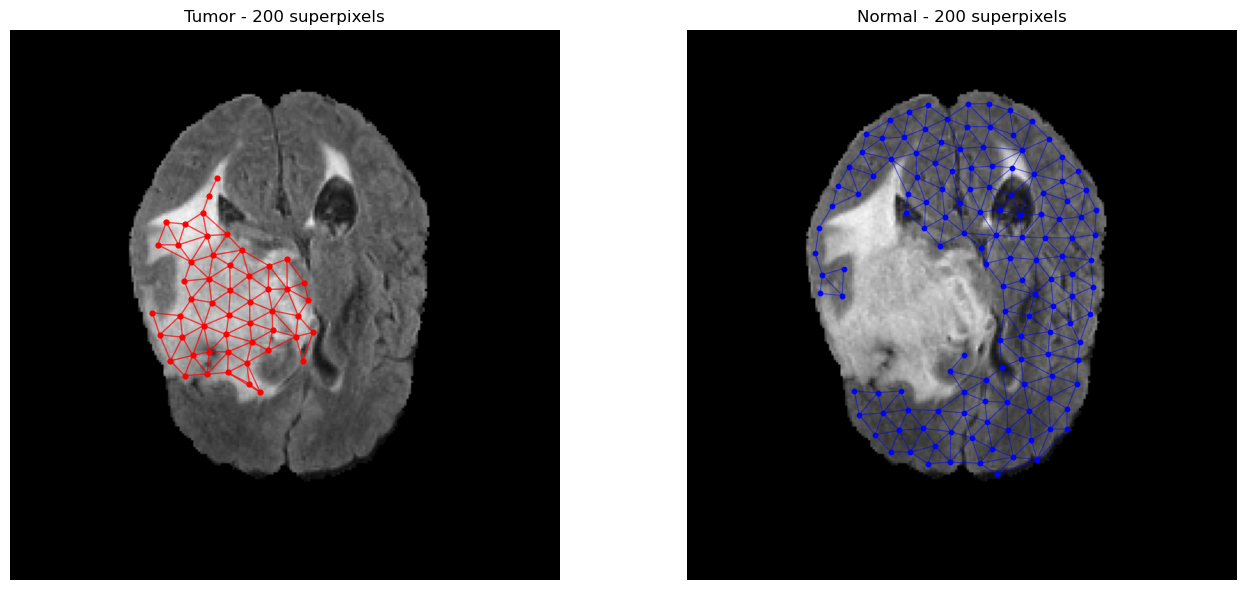

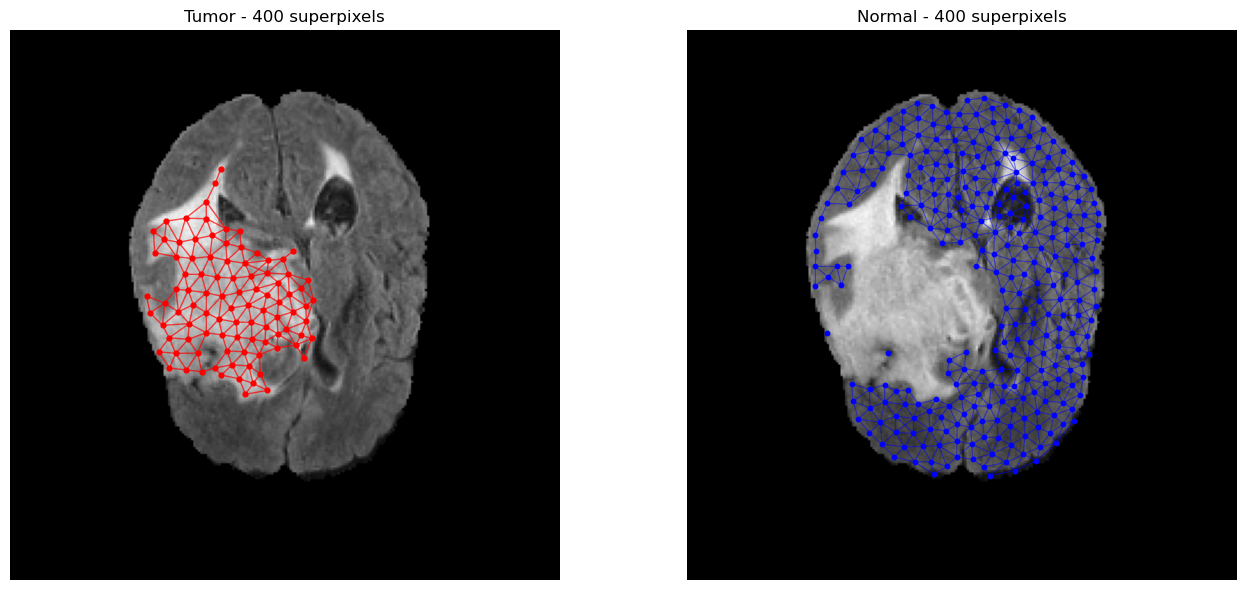

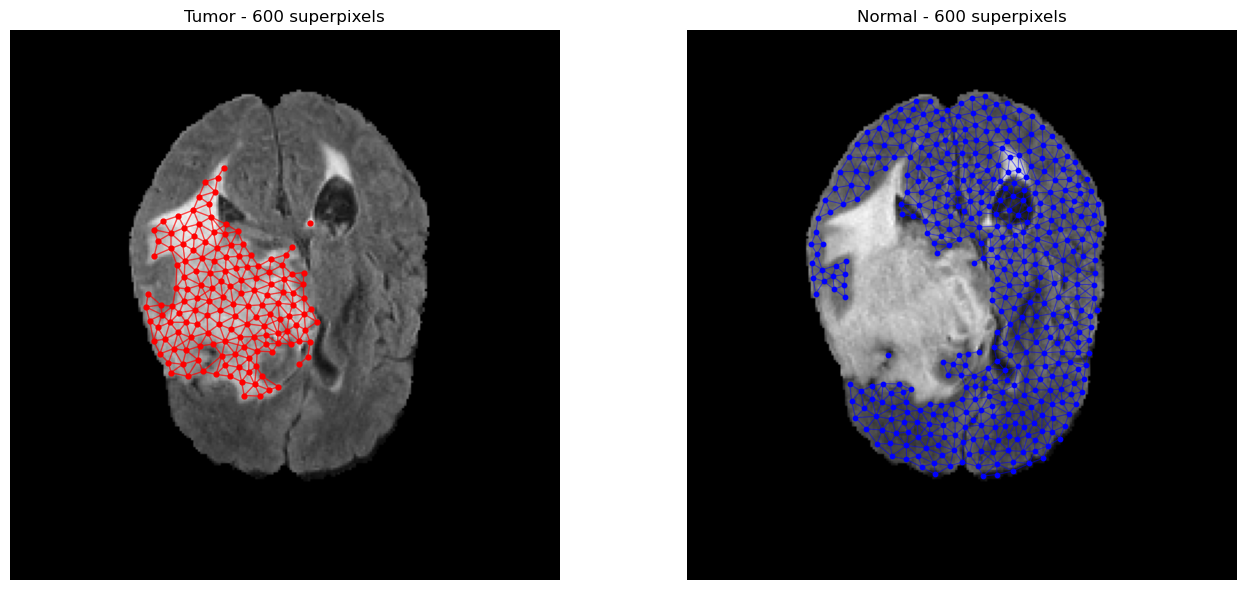

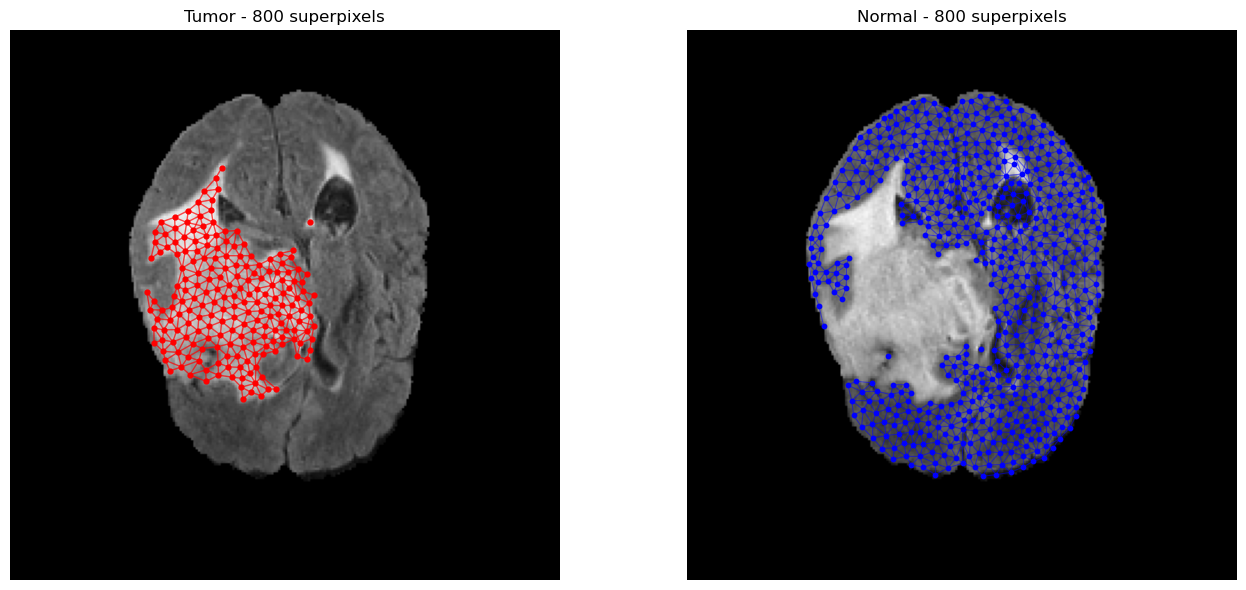

In [24]:
for n_seg in lista_superpixels:

    exp = experimentos[n_seg]

    G = exp["grafo"]
    labels = exp["labels"]
    pos = exp["pos"]

    subgrafos = criar_subgrafos(G, labels)

    G_tumor = subgrafos["tumor"]
    G_normal = subgrafos["normal"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img_norm, cmap="gray")

    for u, v in G_tumor.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]

        axes[0].plot(
            [x1, x2],
            [y1, y2],
            color="red",
            linewidth=1,
            alpha=0.7
        )

    tumor_nodes = list(G_tumor.nodes())
    axes[0].scatter(
        [pos[n][0] for n in tumor_nodes],
        [pos[n][1] for n in tumor_nodes],
        c="red",
        s=12
    )

    axes[0].set_title(f"Tumor - {n_seg} superpixels")
    axes[0].axis("off")


    axes[1].imshow(img_norm, cmap="gray")

    for u, v in G_normal.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]

        axes[1].plot(
            [x1, x2],
            [y1, y2],
            color="blue",
            linewidth=0.8,
            alpha=0.5
        )

    normal_nodes = list(G_normal.nodes())
    axes[1].scatter(
        [pos[n][0] for n in normal_nodes],
        [pos[n][1] for n in normal_nodes],
        c="blue",
        s=10
    )

    axes[1].set_title(f"Normal - {n_seg} superpixels")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
df_subgrafos = pd.DataFrame(resultados_subgrafos)
df_subgrafos

,Superpixels,Nós Tumor,Arestas Tumor,Grau Médio Tumor,Densidade Tumor,Componentes Tumor,Nós Normal,Arestas Normal,Grau Médio Normal,Densidade Normal,Componentes Normal
0,200,52,122,4.692308,0.092006,1,137,338,4.934307,0.036282,1
1,400,96,239,4.979167,0.052412,1,293,776,5.296928,0.018140,3
2,600,152,390,5.131579,0.033984,2,435,1170,5.379310,0.012395,2
3,800,197,514,5.218274,0.026624,2,589,1608,5.460102,0.009286,3
